[CircuitInstruction(operation=Instruction(name='swap', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(2, 'q'), 1), Qubit(QuantumRegister(2, 'q'), 0)), clbits=()), CircuitInstruction(operation=Instruction(name='t', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(2, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='y', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(2, 'q'), 1),), clbits=()), CircuitInstruction(operation=Instruction(name='u2', num_qubits=1, num_clbits=0, params=[1.1113350121433627, 0.34167958267270276]), qubits=(Qubit(QuantumRegister(2, 'q'), 1),), clbits=()), CircuitInstruction(operation=Instruction(name='u2', num_qubits=1, num_clbits=0, params=[1.139940589789354, 1.4801114087328797]), qubits=(Qubit(QuantumRegister(2, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='ry', num_qubits=1, num_clbits=0, params=[0.3102816267756833]), qubits=(Qubit(QuantumRegister(2, '

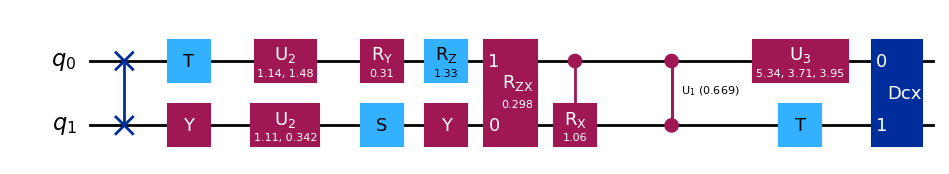

In [1]:
from qiskit import QuantumCircuit
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Statevector

qc = random_circuit(2, max_operands =2, depth = 10)
print(qc.data)
qc.draw('mpl')



In [52]:
# gate latex names and parameters
import json
import numpy as np
import pandas as pd

with open('gates.json', 'r') as file:
    quantum_gates = json.load(file)

def categorize_gate(gate_name):
    gate_name = gate_name.lower()
    for category, gates in quantum_gates.items():
        for gate in gates: 
            if gate_name == gate['name']: 
                return category, gate['latex']
names = []
params = []
idxs = []
categories = []
for instruction in qc.data: 
    category, latex = categorize_gate(instruction.operation.name)

    categories.append(category)
    names.append(latex)
    params.append([i for i in instruction.operation.params if isinstance(i, np.float64)])
    idxs.append([qc.find_bit(qubit).index for qubit in instruction.qubits])

circuit_data = pd.DataFrame({
    'category': categories,
    'names': names, 
    'params': params, 
    'idxs': idxs
})

In [53]:
display(circuit_data)

,category,names,params,idxs
0,single_qubit_gates,\sqrt{X}^\dagger,[],[1]
1,single_qubit_gates,U_2,"[4.388365971343252, 0.48718037347360027]",[0]
2,cx_like_gates,CZ,[],"[0, 1]"
3,single_qubit_gates,R_z,[3.860705072436503],[1]
4,single_qubit_gates,Y,[],[0]
5,cx_like_gates,CNOT,[],"[1, 0]"
6,cx_like_gates,SWAP,[],"[0, 1]"
7,general_controlled_gates,\sqrt{X},[],"[1, 0]"
8,cphase_gates,U_3,"[5.726509079017083, 5.15599162397975, 4.947593...","[1, 0]"
9,cx_like_gates,CZ,[],"[0, 1]"


In [54]:
for i, j in circuit_data.iterrows(): 
    print(j.iloc[0])


single_qubit_gates
single_qubit_gates
cx_like_gates
single_qubit_gates
single_qubit_gates
cx_like_gates
cx_like_gates
general_controlled_gates
cphase_gates
cx_like_gates
single_qubit_gates
single_qubit_gates
general_controlled_gates


[CircuitInstruction(operation=Instruction(name='s', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='sdg', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='u1', num_qubits=1, num_clbits=0, params=[0.9057815605287021]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='z', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='u2', num_qubits=1, num_clbits=0, params=[1.9592947975887585, 2.659838524324996]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=())]


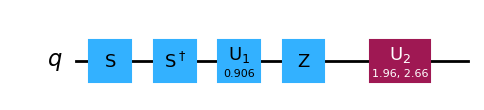

In [55]:
qc1 = random_circuit(1, depth = 5, seed = 1)
print(qc1.data)
qc1.draw('mpl')

[CircuitInstruction(operation=Instruction(name='u', num_qubits=1, num_clbits=0, params=[3.212765766999291, 6.133920107929199, 0.5079077176316655]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=()), CircuitInstruction(operation=Instruction(name='y', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(1, 'q'), 0),), clbits=())]


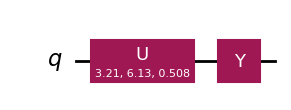

In [56]:
qc2 = random_circuit(1, depth = 2, seed = 4)
print(qc2.data)
qc2.draw('mpl')

In [57]:
zero = Statevector.from_label('0')
q1out = zero.evolve(qc1)
q2out = zero.evolve(qc2)

In [58]:
display(q1out.draw('latex'))
display(q2out.draw('latex'))
display(q1out.tensor(q2out).draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [59]:
import numpy as np

qc = QuantumCircuit(2)

qc.u(3.212765766999291, 6.133920107929199, 0.5079077176316655, 0)
qc.y(0)
qc.s(0)
qc.t(0)
qc.h(0) 

qc.s(1) 
qc.sdg(1)
qc.p(0.9057815605287021, 1)
qc.z(1)
qc.u(np.pi/2, 1.9592947975887585, 2.659838524324996, 1)

zero.tensor(zero).evolve(qc).draw('latex')

<IPython.core.display.Latex object>

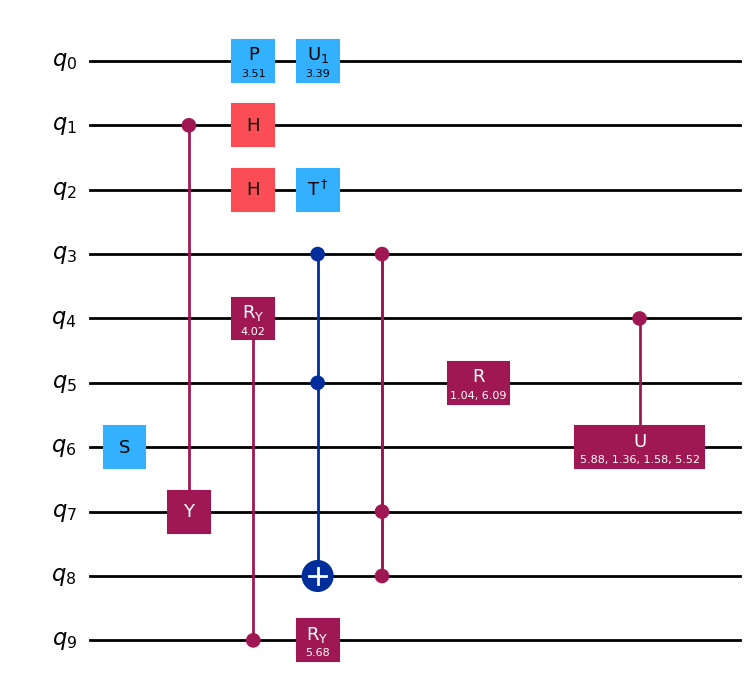

In [60]:
qc = random_circuit(10, depth = 2)
qc.draw('mpl')

In [61]:
qubits = []
for i in qc.data: 
    qubits.append([qc.find_bit(qubit).index for qubit in i.qubits])

qubits

[[6],
 [1, 7],
 [9, 4],
 [0],
 [2],
 [5, 3, 8],
 [1],
 [9],
 [0],
 [8, 3, 7],
 [5],
 [4, 6],
 [2]]

In [62]:
from circuit import BuildCircuit

In [63]:
class_ = BuildCircuit() 
class_.decompose(qc)

,category,names,colors,params,qbits,cbits
0,single_qubit_gates,S,BLUE_C,[],[6],[]
1,cx_like_gates,CY,MAROON_C,[],"[1, 7]",[]
2,general_controlled_gates,R_y,MAROON_C,[4.020897335545814],"[9, 4]",[]
3,single_qubit_gates,P,BLUE_C,[3.505069367593711],[0],[]
4,single_qubit_gates,H,RED_C,[],[2],[]
5,multi_controlled_gates,ccx,MAROON_C,[],"[5, 3, 8]",[]
6,single_qubit_gates,H,RED_C,[],[1],[]
7,single_qubit_gates,R_y,MAROON_C,[5.677957042624283],[9],[]
8,single_qubit_gates,U_1,MAROON_C,[3.388398471796662],[0],[]
9,multi_controlled_gates,ccz,MAROON_C,[],"[8, 3, 7]",[]


In [64]:
np.array(range(qc.num_qubits-1, -qc.num_qubits, -2))

array([ 9,  7,  5,  3,  1, -1, -3, -5, -7, -9])

In [65]:
x_init = np.zeros((10))
x_init[0] = 5
x_init[3] = 10.25

x_init[[0]].tolist()[0]



5.0

KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__del__'
Traceback (most recent call last):
  File "_zmq.py", line 141, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


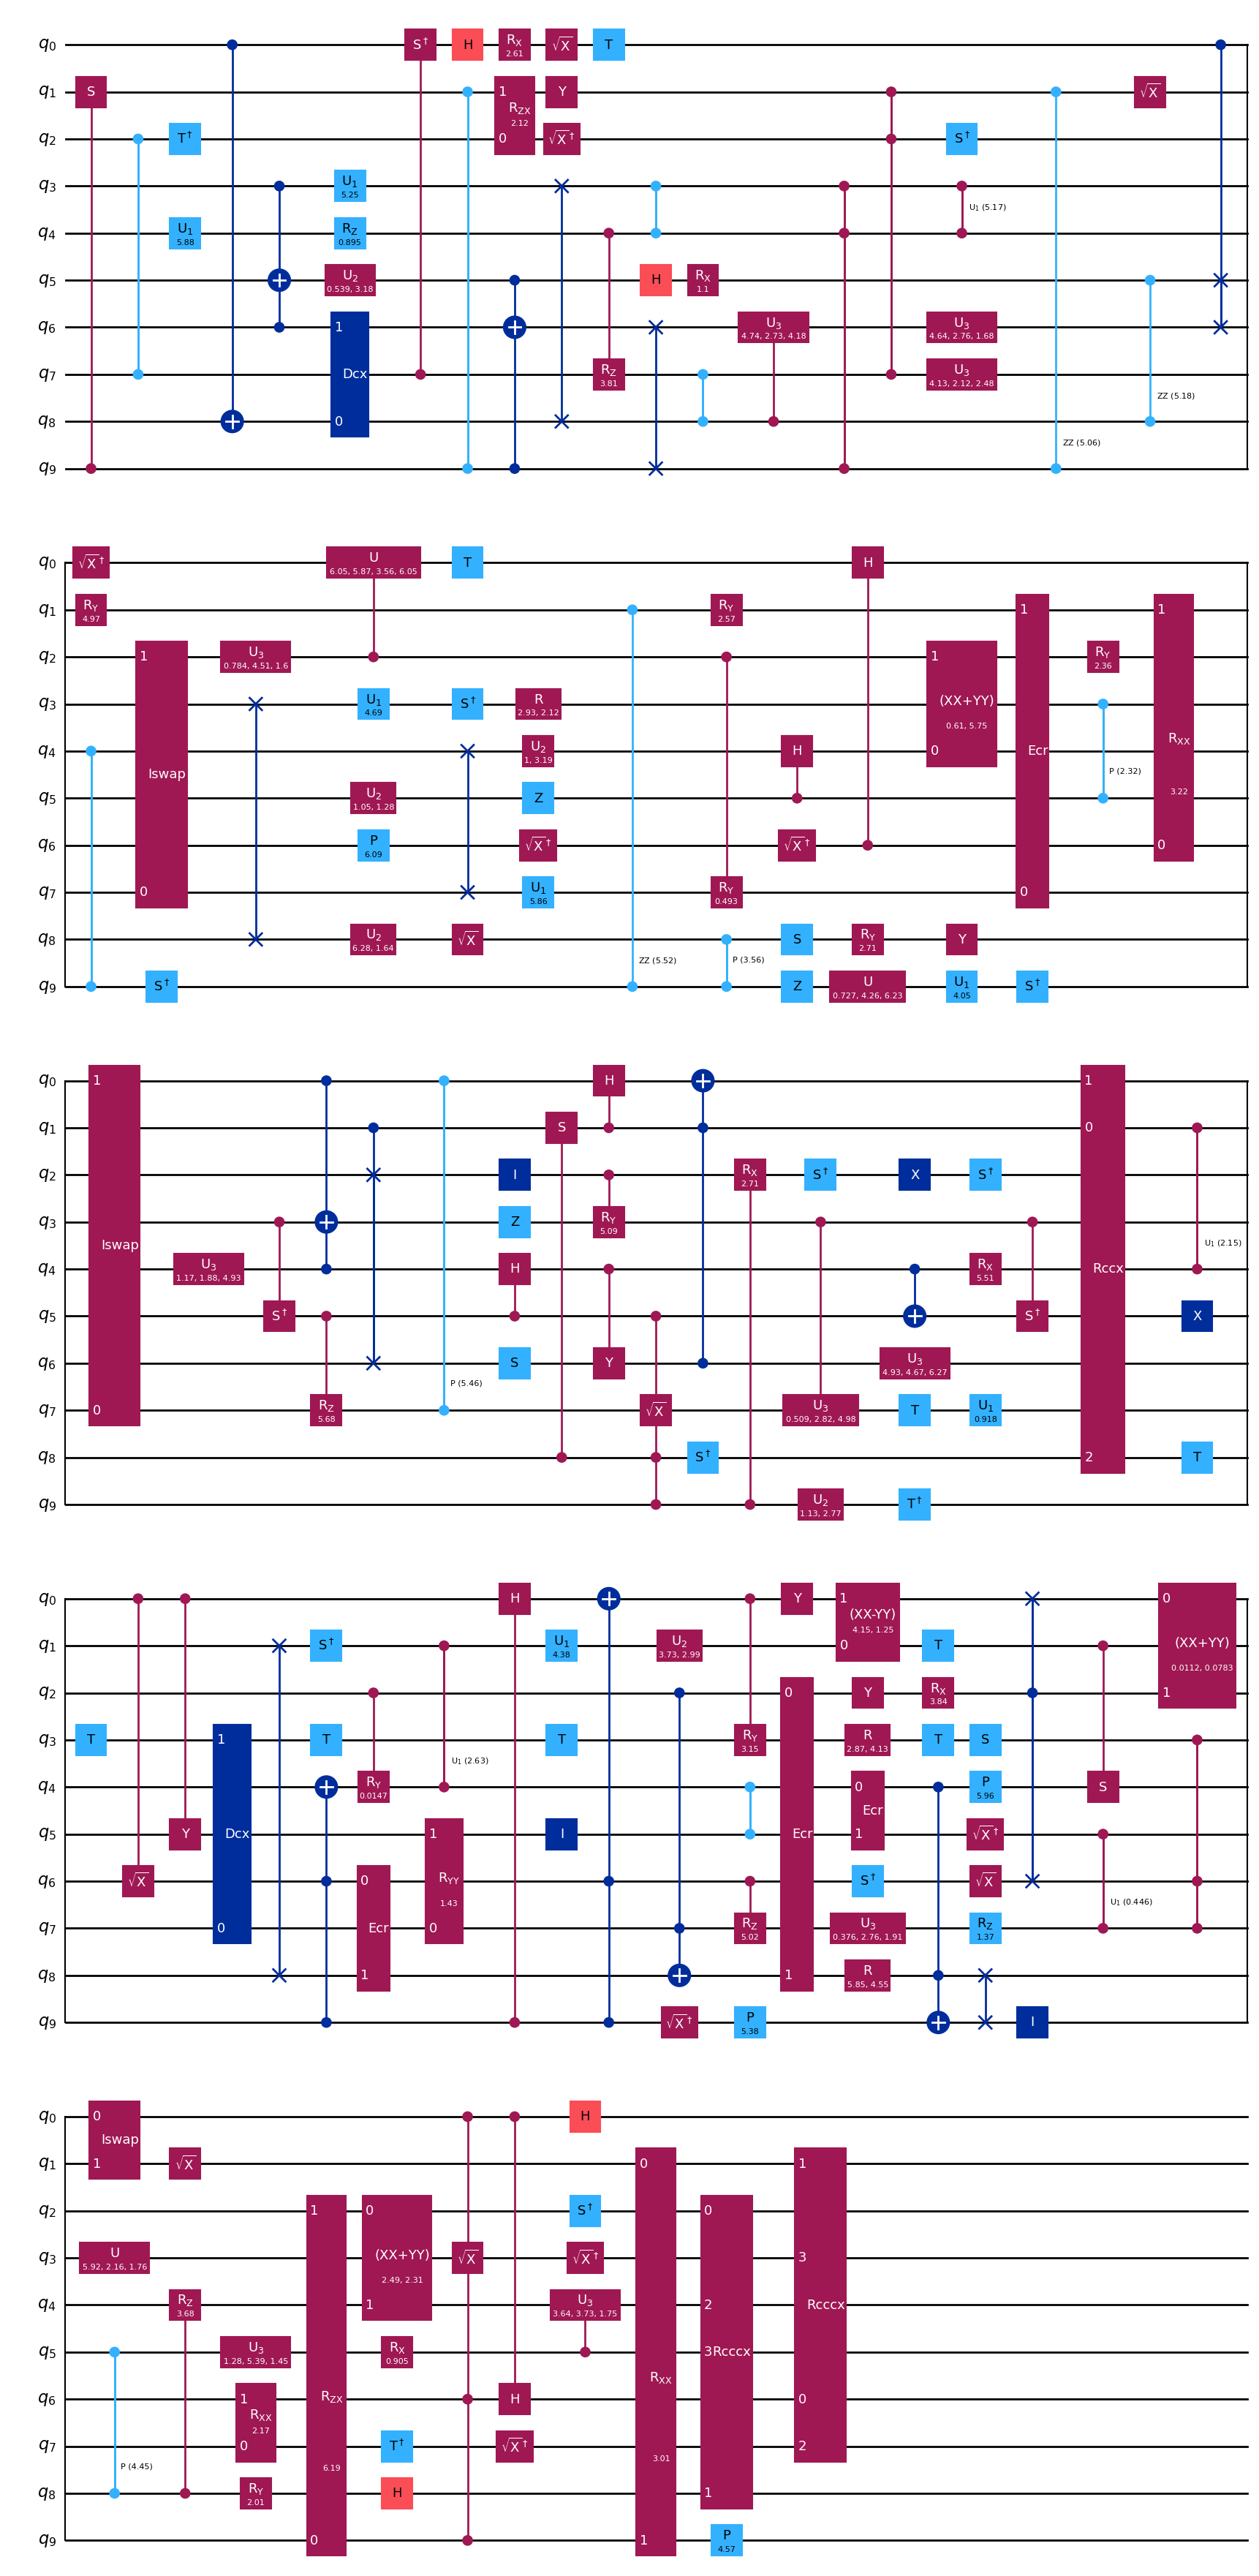

In [66]:
qc = random_circuit(10, max_operands=4, depth = 30)
qc.draw('mpl')

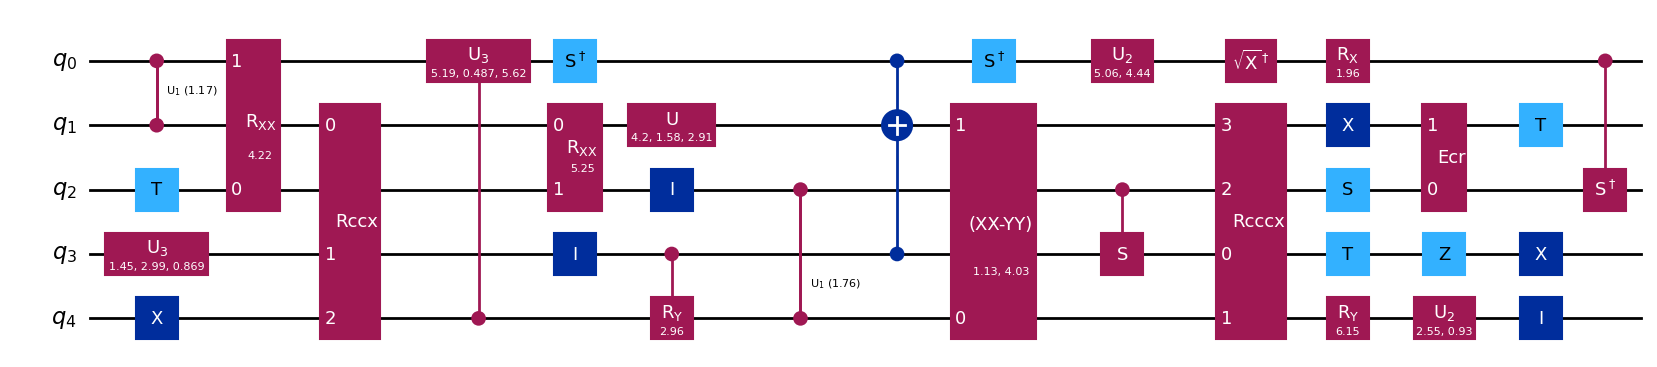

In [ ]:
qc = random_circuit(5, max_operands = 4, depth = 10)


qc.draw('mpl')

In [ ]:
qc.size()

33

In [2]:
from circuit import * 

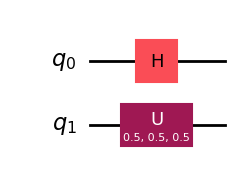

In [72]:
qc = QuantumCircuit(2)
qc.h(0)
qc.u(0.5, 0.5, 0.5, 1)

qc.draw('mpl')

In [3]:
class_ = BuildCircuit()


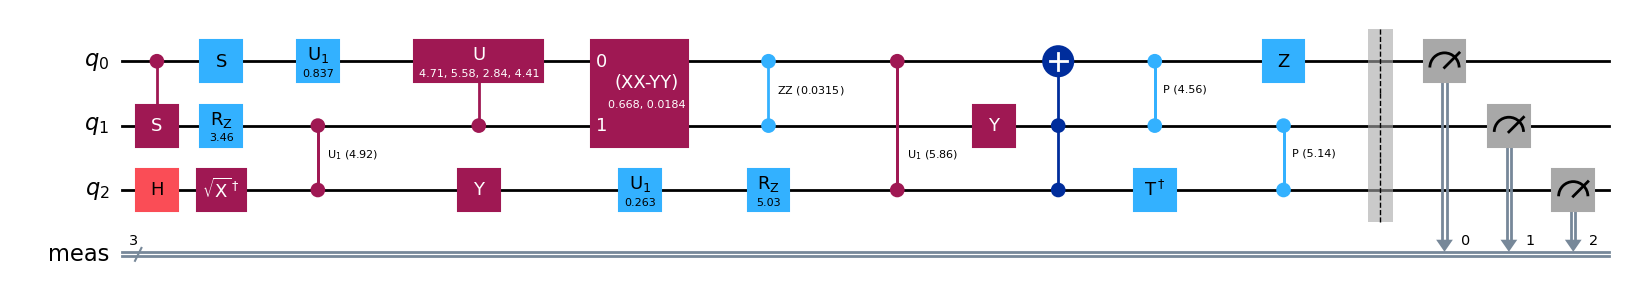

[10/31/24 14:45:45] INFO     Writing 4.71, 5.58, 2.84, 4.41 to                              ]8;id=735855;file:///Users/devaldeliwala/miniconda3/lib/python3.12/site-packages/manim/utils/tex_file_writing.py\tex_file_writing.py]8;;\:]8;id=941857;file:///Users/devaldeliwala/miniconda3/lib/python3.12/site-packages/manim/utils/tex_file_writing.py#109\109]8;;\
                             media/Tex/49ac08376b1b0756.tex                                                        

[10/31/24 14:45:46] INFO     Writing 0.67, 0.02 to media/Tex/f3437035a67d9223.tex           ]8;id=448165;file:///Users/devaldeliwala/miniconda3/lib/python3.12/site-packages/manim/utils/tex_file_writing.py\tex_file_writing.py]8;;\:]8;id=552329;file:///Users/devaldeliwala/miniconda3/lib/python3.12/site-packages/manim/utils/tex_file_writing.py#109\109]8;;\

[10/31/24 14:45:59] INFO     Animation 12 : Partial movie file written in                  ]8;id=900575;file:///Users/devaldeliwala/miniconda3/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=760494;file:///Users/devaldeliwala/miniconda3/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#527\527]8;;\
                             '/Users/devaldeliwala/ManiQ/src/media/videos/1080p60/partial_                         
                             movie_files/BuildCircuit/2852726489_1231454839_1679570609.mp4                         
                             '                                                                                     

[10/31/24 14:46:01] INFO     Animation 13 : Partial movie file written in                  ]8;id=306644;file:///Users/devaldeliwala/miniconda3/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=985530;file:///Users/devaldeliwala/miniconda3/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#527\527]8;;\
                             '/Users/devaldeliwala/ManiQ/src/media/videos/1080p60/partial_                         
                             movie_files/BuildCircuit/2852726489_123554531_665832710.mp4'                          

4
{-2}
3
{-2}
{0, -2}
1
{0, -2}
3
{0, 2}
2
{0, 2}
0
0
0
1
{0}
2
{-2}
1
{2}
0
0
0
0


[[VGroup(Rectangle, VGroup of 2 submobjects),
  VGroup(Dot, Dot, Line, MathTex('S'))],
 [VGroup(Rectangle, VGroup of 2 submobjects),
  VGroup(Rectangle, VGroup of 2 submobjects),
  VGroup(Rectangle, VGroup of 2 submobjects)],
 [VGroup(Dot, Dot, Line, MathTex('U_1 \\; (4.9)')),
  VGroup(Rectangle, VGroup of 2 submobjects)],
 [VGroup(Dot, VGroup of 2 submobjects, Line),
  VGroup(Rectangle, VGroup of 2 submobjects)],
 [VGroup(Rectangle, VGroup of 2 submobjects),
  VGroup(Rectangle, VGroup of 2 submobjects)],
 [VGroup(Rectangle, VGroup of 2 submobjects)],
 [VGroup(Dot, Dot, Line, MathTex('ZZ \\; (0.0)'))],
 [VGroup(Dot, Dot, Line, MathTex('U_1 \\; (5.9)'))],
 [VGroup(Rectangle, VGroup of 2 submobjects),
  VGroup(Rectangle, VGroup of 2 submobjects)],
 [VGroup(Rectangle, VGroup of 2 submobjects),
  VGroup(Dot, Dot, Line, MathTex('P \\; (4.6)'))],
 [VGroup(Rectangle, VGroup of 2 submobjects),
  VGroup(Dot, Dot, Line, MathTex('P \\; (5.1)'))],
 [VGroup(Rectangle, DashedLine)],
 [VGroup(Line, L

15


In [11]:
qc = random_circuit(3, depth=10)
qc.measure_all()
display(qc.draw('mpl'))

mobjects = class_.build(qc)
class_.construct(qc)

wire_pos = list(range(-qc.num_qubits+1, qc.num_qubits, 2))
def group_by_column(objects):
    gate_count = 0
    columns = []
    while gate_count < len(objects):
        start_object = objects[gate_count]
        start_height = start_object.height
        start_y = start_object.get_y()

        initial_wires = [
            wire for wire in wire_pos if start_y-start_height/2 <= wire <= start_y+start_height/2
        ]
        
        filtered_objects = []
        for obj in objects[gate_count+1:]: 
            intersecting_wires = [
                wire for wire in wire_pos if obj.get_y() - obj.height/2 <= wire <= obj.get_y()+obj.height/2
            ]
            if all(obj not in col for col in columns): 
                if abs(obj.get_x() - start_object.get_x()) <= 5: 
                    if not any(val in initial_wires for val in intersecting_wires): 
                        filtered_objects.append(obj)
        print(len(filtered_objects))

        individual_column = [start_object]
        intersecting_wires = [
            num for num in wire_pos if start_y-start_height/2 <= num <= start_y+start_height/2
        ]

        stored_y_positions = set(intersecting_wires)

        for obj in filtered_objects:
            obj_y = obj.get_y()
            obj_height = obj.height

            current_intersecting_wires = [
                num for num in wire_pos if obj_y-obj_height <= num <= obj_y+obj_height
            ]
            if not any(y_pos in stored_y_positions for y_pos in current_intersecting_wires):
                individual_column.append(obj)
                print(stored_y_positions)
                stored_y_positions.update(current_intersecting_wires)
                gate_count+=1

        columns.append(individual_column)
        gate_count+=1

    return columns

columns = group_by_column(mobjects)
display(columns)
print(len(columns))

In [10]:
qc.size()

21

In [123]:
columns

[[VGroup(Rectangle, VGroup of 2 submobjects),
  VGroup(Rectangle, VGroup of 2 submobjects),
  VGroup(Rectangle, VGroup of 2 submobjects),
  VGroup(Rectangle, VGroup of 2 submobjects),
  VGroup(Rectangle, VGroup of 2 submobjects)],
 [VGroup(Rectangle, VGroup of 2 submobjects),
  VGroup(Rectangle, VGroup of 2 submobjects)],
 VGroup(Rectangle, VGroup of 2 submobjects)]

In [186]:
x = [5, 4, 6, 7]
x[1:]

[4, 6, 7]

[CircuitInstruction(operation=Instruction(name='ch', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(3, 'q'), 2), Qubit(QuantumRegister(3, 'q'), 0)), clbits=()), CircuitInstruction(operation=Instruction(name='z', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(3, 'q'), 1),), clbits=()), CircuitInstruction(operation=Instruction(name='ecr', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(3, 'q'), 1), Qubit(QuantumRegister(3, 'q'), 0)), clbits=()), CircuitInstruction(operation=Instruction(name='p', num_qubits=1, num_clbits=0, params=[2.659838524324996]), qubits=(Qubit(QuantumRegister(3, 'q'), 2),), clbits=())]

[CircuitInstruction(operation=Instruction(name='ch', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(3, 'q'), 2), Qubit(QuantumRegister(3, 'q'), 0)), clbits=()), CircuitInstruction(operation=Instruction(name='z', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(3, 'q'), 1),), clbits=()), CircuitInstruction(operation=Instruction(name='p', num_qubits=1, num_clbits=0, params=[2.659838524324996]), qubits=(Qubit(QuantumRegister(3, 'q'), 2),), clbits=()), CircuitInstruction(operation=Instruction(name='ecr', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(3, 'q'), 0), Qubit(QuantumRegister(3, 'q'), 1)), clbits=())]

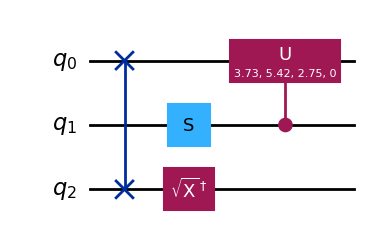

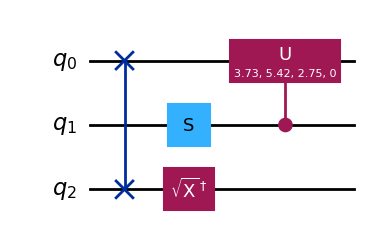

In [152]:
from qiskit import QuantumCircuit

def reorder_instructions(qc):
    qubit_times = {i: 0 for i in range(qc.num_qubits)}
    ordered_instructions = []

    for instruction in qc.data:
        qubits = [qc.find_bit(qubit).index for qubit in instruction.qubits]
        start_time = max(qubit_times[q] for q in qubits)
        ordered_instructions.append((start_time, instruction))
        
        min_qubit, max_qubit = min(qubits), max(qubits)
        for q in range(min_qubit, max_qubit+1):
            qubit_times[q] = start_time + 1

    ordered_instructions.sort(key=lambda x: x[0])

    new_qc = QuantumCircuit(qc.num_qubits)
    new_qc.add_register(*qc.cregs)
    for _, inst in ordered_instructions:
        new_qc.append(inst.operation, inst.qubits, inst.clbits)
    
    return new_qc



qc = QuantumCircuit(3)
qc.swap(2, 0)
qc.s(1)
qc.cu(3.73, 5.42, 2.75, 0, control_qubit=1, target_qubit=0)
qc.sxdg(2)
qc_new = reorder_instructions(qc)

display(qc.draw('mpl'))
display(qc_new.draw('mpl'))

In [153]:
for i in qc.data:
    print(i.operation.name)

swap
s
cu
sxdg


In [154]:
for i in qc_new.data:
    print(i.operation.name)

swap
s
sxdg
cu


In [100]:
qc_new.data

[CircuitInstruction(operation=Instruction(name='swap', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(3, 'q'), 0), Qubit(QuantumRegister(3, 'q'), 2)), clbits=()), CircuitInstruction(operation=Instruction(name='s', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(3, 'q'), 1),), clbits=()), CircuitInstruction(operation=Instruction(name='cu', num_qubits=2, num_clbits=0, params=[3.73, 5.42, 2.75, 0]), qubits=(Qubit(QuantumRegister(3, 'q'), 1), Qubit(QuantumRegister(3, 'q'), 0)), clbits=()), CircuitInstruction(operation=Instruction(name='sxdg', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(3, 'q'), 2),), clbits=())]